## Imports

In [1]:
from RegionMap import RegionMap
from Fleet import Monitoring_Fleet

import numpy as np
import os 
from datetime import datetime
import pandas as pd

## Set up

In [2]:
# Path to load the data

# Amélie
link = r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg"
df_link = pd.read_csv(r"D:\EPFL\MA2\Projet\Code\Data\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

# # Orane
# link = r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg"
# df_link = pd.read_csv(r"C:\Users\orane\Documents\EPFL\GC\Master\MA2\Projet LUTS\all_agg\datasets\simbarca\all_agg\metadata\link_bboxes_clustered.csv")

In [3]:
def run(link, df_link, File, id = 'pred_vdist', mode = 'random', load = True):

    
    # Set the parameters
    N_episodes = 300 
    ep_len     = 5

    buffer_size = 6000
    batch_size = 32

    # --- Create maps --- 

    # Map parameters
    x_size = 20
    y_size = 30


    Map = RegionMap(y_size, x_size, [], [], 1, df_link = df_link, link = link, listFileNumbers=File, load = load)
    Map.initialize_better_importance_map(id)

    # ----- Create a fleet -----
    
    drone_init_pos = [[5,7], [3,26], [10, 3], [10,26]]

    state_shape    = [ep_len, 13]    
    num_stacked = 2    
    alpha = 1e-3

    pretrained_folder = None 

    F = Monitoring_Fleet(Map, buffer_size, state_shape, pretrained_folder, True, num_stacked, alpha)
    F.add_drones(drone_init_pos) 


    #----- Create save folder paths -----
    
    np.set_printoptions(threshold=np.inf)
    
    current_folder = os.getcwd()
    save_folder = current_folder + "/Results"
    if not os.path.exists(save_folder):
        os.makedirs(save_folder)    
        
    now = datetime.now()
    date_time = now.strftime("%m_%d_%Y_%H_%M_%S")    
    
    current_results = save_folder + "/" + date_time
    if not os.path.exists(current_results):
        os.makedirs(current_results)

   #----- Simultaion -----
    
    t_curr = 0
    
    ep_curr = 0 
    ep_step = 0

    ep_len = 0
    
    T = Map.importance_map.shape[0] -1


    list_of_importance_metric = []
    list_of_patrol_metric     = []
    list_of_reward_metric     = []
    
    while t_curr < T:

        # ------------------------------------------------------------------------------------------
        
        if t_curr % 1 == 0:
            F.plot_fleets_trajectories(t_curr, T, masked=True)
        
        if t_curr == 0:
        
            list_of_observations, list_of_drone_positions = F.get_fleet_info(t_curr, T)
            list_of_drone_states = F.get_drone_states(list_of_observations, list_of_drone_positions)
            visit_matrix = F.visit_matrix
            
            F.update_drone_state_history(list_of_drone_states)                   
            
        #------------- MOVE -------------------------------------------------------------------------------------
        if mode == 'random':
            list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
        elif mode == 'greedy':
            list_of_actions = F.move_drones_greedy(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
        else:
            if t_curr > ep_len:
                list_of_actions = F.move_drones_LSTM(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
            
            else:
                list_of_actions = F.move_drones_random(list_of_drone_states, list_of_observations, discount_param=0.1, recover_param=0.025)
        #--------------------------------------------------------------------------------------------------------------------
        
        F.update_drone_action_history(list_of_actions)
        
        list_of_observations_, list_of_drone_positions_ = F.get_fleet_info(t_curr+1, T)
        list_of_drone_states_ = F.get_drone_states(list_of_observations_, list_of_drone_positions_)
        print(f"Length of drone state's vector: {len(list_of_drone_states_)}")
        print(f"What is inside: {list_of_drone_states_}")
        visit_matrix_ = F.visit_matrix
        
        F.update_drone_state_history(list_of_drone_states_)
        
        #----- Reward calculation -----
    
        list_of_rewards = F.get_reward(list_of_observations, list_of_observations_, visit_matrix, visit_matrix_, alpha1=1.0, alpha2=0.5)
        
        F.update_drone_reward_history(list_of_rewards)
        
        #----- Collect metrics -----
    
        importance_metric, patrol_metric, reward_metric = F.get_metrics(list_of_rewards)
    
        list_of_importance_metric.append(importance_metric)
        list_of_patrol_metric.append(patrol_metric)
        list_of_reward_metric.append(reward_metric)  
        
        #----- Re-assign states for next iteration -----
    
        list_of_observations    = list_of_observations_
        list_of_drone_positions = list_of_drone_positions_
        list_of_drone_states    = list_of_drone_states_
    
        t_curr  += 1 
        ep_step +=1

    #----- Store transitions in the buffer -----
        
    ep_curr += 1
    
    print("-----------")
    
    F.create_data_set()
    
    F.buffer.save(current_results)

    #----- Save metrics -----
    
    np.save(current_results + "/list_of_importance_metric.npy", np.array(list_of_importance_metric))
    np.save(current_results + "/list_of_patrol_metric.npy"    , np.array(list_of_patrol_metric))
    np.save(current_results + "/list_of_reward_metric.npy"    , np.array(list_of_reward_metric))
    np.save(current_results + "/list_of_perc_visited.npy"     , np.array(F.procentage_visited))

# Test

In [ ]:
filename = 'ld_speed_map.npy'

path = os.getcwd() + '/Map_configurations'
file_path = path + '/' + filename

data = np.load(file_path)
imp_map = np.array(data, dtype=np.float32)

v_size = np.shape(imp_map)[2]
h_size = np.shape(imp_map)[1]

In [6]:
imp_map.shape

(131, 20, 30)

## Run

AttributeError: 'RegionMap' object has no attribute 'our_importance_map'

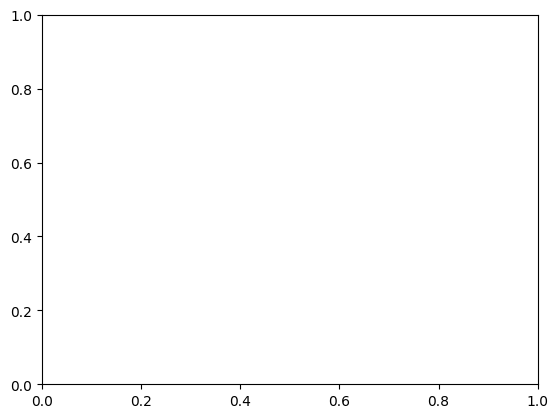

In [4]:
# Set mode: random, greedy, lstm, nn
mode = 'greedy'
run(link, df_link, ['000'], id = 'pred_vdist', mode = 'random', load = True)